In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

In [3]:
# Loading the statistic files
df = pd.read_excel("output/merged_output_with_sv_stats.xlsx")

print("SV stats shape:", df.shape)
print(df.head())
print(df.columns.tolist())

SV stats shape: (21225, 32)
   SUBJECT_ID  HADM_ID  VISIT_ID    MONITORTIME  SV1_min  SV1_max   SV1_mean  \
0           4   102191         1  9/25/81 18:40     67.0     95.0  77.461538   
1           4   102191         1  9/25/81 19:45     73.0     92.0  80.846154   
2           4   102191         1  9/25/81 20:50     70.0    116.0  91.461538   
3           4   102191         1  9/25/81 21:55     83.0     95.0  88.000000   
4          37   102040         1  8/12/71 11:00     70.0     99.0  84.928571   

   SV1_median  SV2_min  SV2_max  ...  SV5_mean  SV5_median  SV6_min  SV6_max  \
0        74.0     68.0     97.0  ...       NaN         NaN      NaN      NaN   
1        82.0     74.0     92.0  ...       NaN         NaN      NaN      NaN   
2        86.0     10.0     99.0  ...       NaN         NaN      NaN      NaN   
3        86.0     83.0     99.0  ...       NaN         NaN      NaN      NaN   
4        84.0     71.0    100.0  ...       NaN         NaN     16.0     26.0   

    SV6_me

In [6]:
# Standardize column names just in case
df.columns = [c.strip() for c in df.columns]

# Convert MONITORTIME to datetime
if "MONITORTIME" in df.columns:
    df["MONITORTIME"] = pd.to_datetime(df["MONITORTIME"], errors="coerce")

# Check key columns
required_keys = ["SUBJECT_ID", "HADM_ID"]
for col in required_keys:
    if col not in df.columns:
        raise ValueError(f"{col} not found in SV statistics file")

print(df[["SUBJECT_ID", "HADM_ID"]].head())

/var/folders/6c/h_2qq_495412tl4y7hpdmk5c0000gn/T/ipykernel_28728/2369392181.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["MONITORTIME"] = pd.to_datetime(df["MONITORTIME"], errors="coerce")


   SUBJECT_ID  HADM_ID
0           4   102191
1           4   102191
2           4   102191
3           4   102191
4          37   102040


Target variable : HOSPITAL_EXPIRE_FLAG

In [7]:
# Load the ADMISSIONS.csv file

admissions = pd.read_csv("../paediatric-intensive-care-database-1.1.0/ADMISSIONS.csv")

print("ADMISSIONS shape:", admissions.shape)
print(admissions[["SUBJECT_ID", "HADM_ID", "HOSPITAL_EXPIRE_FLAG", "ICD10_CODE_CN"]].head())

ADMISSIONS shape: (13449, 19)
   SUBJECT_ID  HADM_ID  HOSPITAL_EXPIRE_FLAG ICD10_CODE_CN
0          26   100000                     0       K52.901
1          28   100001                     1       I51.403
2          29   100002                     0       T75.101
3          30   100003                     1           NaN
4          31   100004                     1       K52.904


In [8]:
#Step 5 — Merge ADMISSIONS(HOSPITAL_EXPIRE_FLAG) into Your SV Statistics Dataset

admissions_subset = admissions[
    ["SUBJECT_ID", "HADM_ID", "HOSPITAL_EXPIRE_FLAG", "ICD10_CODE_CN", "DIAGNOSIS"]
].copy()

df = df.merge(
    admissions_subset,
    on=["SUBJECT_ID", "HADM_ID"],
    how="left"
)

print("After ADMISSIONS merge:", df.shape)
print(df[["SUBJECT_ID", "HADM_ID", "HOSPITAL_EXPIRE_FLAG"]].head())

After ADMISSIONS merge: (21225, 35)
   SUBJECT_ID  HADM_ID  HOSPITAL_EXPIRE_FLAG
0           4   102191                     0
1           4   102191                     0
2           4   102191                     0
3           4   102191                     0
4          37   102040                     0


Target variable : ICD_CATEGORY

In [9]:
# Load the DIAGNOSES_ICD.csv file
diagnoses = pd.read_csv("../paediatric-intensive-care-database-1.1.0/DIAGNOSES_ICD.csv")
diagnoses.head()

,ROW_ID,SUBJECT_ID,HADM_ID,SEQ_NUM,ICD10_CODE_CN
0,1,12575,113742,1,Q43.901
1,2,614,100603,1,G04.916
2,3,1888,101880,1,Q40.001
3,4,8792,108934,1,S02.902
4,5,10368,111492,1,J18.900


In [10]:
# Get the primary diagnosis for each admission
primary_diag = (
    diagnoses
    .sort_values(["SUBJECT_ID","HADM_ID","SEQ_NUM"])
    .groupby(["SUBJECT_ID","HADM_ID"])
    .first()
    .reset_index()
)

In [11]:
diag_dict = pd.read_csv("../paediatric-intensive-care-database-1.1.0/D_ICD_DIAGNOSES.csv")
diag_dict.head()

,ROW_ID,ICD10_CODE_CN,ICD10_CODE,TITLE_CN,TITLE
0,1,A00.000,A00.0,古典生物型霍乱,"Cholera due to Vibrio cholerae 01, biovar chol..."
1,2,A00.100,A00.1,埃尔托型霍乱,"Cholera due to Vibrio cholerae 01, biovar eltor"
2,3,A00.900,A00.9,霍乱,"Cholera, unspecified"
3,4,A01.000,A01.0,伤寒,Typhoid fever
4,5,A01.001,A01.0,伤寒,Typhoid fever


In [12]:
# Merge primary diagnosis with the diagnosis dictionary to get the ICD10_CODE and TITLE
primary_diag = primary_diag.merge(
    diag_dict[['ICD10_CODE_CN', 'ICD10_CODE', 'TITLE']],
    on='ICD10_CODE_CN',
    how='left'
)

In [13]:
# Mering the primary diagnosis back to the main dataframe

df = df.merge(
    primary_diag[['SUBJECT_ID','HADM_ID','ICD10_CODE','TITLE']],
    on=['SUBJECT_ID','HADM_ID'],
    how='left'
)

In [14]:
df.shape
df.head()


,SUBJECT_ID,HADM_ID,VISIT_ID,MONITORTIME,SV1_min,SV1_max,SV1_mean,SV1_median,SV2_min,SV2_max,...,SV6_median,SV7_min,SV7_max,SV7_mean,SV7_median,HOSPITAL_EXPIRE_FLAG,ICD10_CODE_CN,DIAGNOSIS,ICD10_CODE,TITLE
0,4,102191,1,1981-09-25 18:40:00,67.0,95.0,77.461538,74.0,68.0,97.0,...,NaN,100.0,100.0,100.000000,100.0,0,K56.202,肠扭转,K56.2,Volvulus
1,4,102191,1,1981-09-25 19:45:00,73.0,92.0,80.846154,82.0,74.0,92.0,...,NaN,100.0,100.0,100.000000,100.0,0,K56.202,肠扭转,K56.2,Volvulus
2,4,102191,1,1981-09-25 20:50:00,70.0,116.0,91.461538,86.0,10.0,99.0,...,NaN,100.0,100.0,100.000000,100.0,0,K56.202,肠扭转,K56.2,Volvulus
3,4,102191,1,1981-09-25 21:55:00,83.0,95.0,88.000000,86.0,83.0,99.0,...,NaN,73.0,100.0,94.600000,100.0,0,K56.202,肠扭转,K56.2,Volvulus
4,37,102040,1,2071-08-12 11:00:00,70.0,99.0,84.928571,84.0,71.0,100.0,...,16.0,98.0,100.0,99.538462,100.0,0,K83.502,胆总管囊肿,K83.5,Biliary cyst


https://icd.who.int/browse10/2019/en#/I

In [15]:
#Instead of using 9778 disease titles, group them into clinical categories.
#9778 diagnoses → ~15–20 clinically meaningful categories
#This is much better for modeling and interpretation.

#Machine learning models struggle when:

#Classes >> samples per class

In [16]:
def icd_category(icd):
    if pd.isna(icd):
        return "Unknown"

    letter = icd[0]

    mapping = {
        'A': 'Infectious',
        'B': 'Infectious',
        'C': 'Neoplasms',
        'D': 'Blood/Immune',
        'E': 'Endocrine/Metabolic',
        'F': 'Mental',
        'G': 'Nervous system',
        'H': 'Eye/Ear',
        'I': 'Circulatory',
        'J': 'Respiratory',
        'K': 'Digestive',
        'L': 'Skin',
        'M': 'Musculoskeletal',
        'N': 'Genitourinary',
        'O': 'Pregnancy',
        'P': 'Perinatal',
        'Q': 'Congenital',
        'R': 'Symptoms',
        'S': 'Injury',
        'T': 'Injury',
        'V': 'External cause',
        'W': 'External cause',
        'X': 'External cause',
        'Y': 'External cause'
    }

    return mapping.get(letter, "Other")

df["ICD_CATEGORY"] = df["ICD10_CODE"].apply(icd_category)

In [17]:
df["ICD_CATEGORY"].value_counts()

ICD_CATEGORY
Congenital             8928
Digestive              2703
Symptoms               1817
Circulatory            1456
Other                   973
Perinatal               969
Blood/Immune            904
Respiratory             874
Nervous system          748
Injury                  696
Genitourinary           374
Neoplasms               243
Endocrine/Metabolic     168
Musculoskeletal         123
Infectious               83
External cause           62
Skin                     53
Eye/Ear                  38
Unknown                  10
Mental                    3
Name: count, dtype: int64

In [18]:
df.head()

,SUBJECT_ID,HADM_ID,VISIT_ID,MONITORTIME,SV1_min,SV1_max,SV1_mean,SV1_median,SV2_min,SV2_max,...,SV7_min,SV7_max,SV7_mean,SV7_median,HOSPITAL_EXPIRE_FLAG,ICD10_CODE_CN,DIAGNOSIS,ICD10_CODE,TITLE,ICD_CATEGORY
0,4,102191,1,1981-09-25 18:40:00,67.0,95.0,77.461538,74.0,68.0,97.0,...,100.0,100.0,100.000000,100.0,0,K56.202,肠扭转,K56.2,Volvulus,Digestive
1,4,102191,1,1981-09-25 19:45:00,73.0,92.0,80.846154,82.0,74.0,92.0,...,100.0,100.0,100.000000,100.0,0,K56.202,肠扭转,K56.2,Volvulus,Digestive
2,4,102191,1,1981-09-25 20:50:00,70.0,116.0,91.461538,86.0,10.0,99.0,...,100.0,100.0,100.000000,100.0,0,K56.202,肠扭转,K56.2,Volvulus,Digestive
3,4,102191,1,1981-09-25 21:55:00,83.0,95.0,88.000000,86.0,83.0,99.0,...,73.0,100.0,94.600000,100.0,0,K56.202,肠扭转,K56.2,Volvulus,Digestive
4,37,102040,1,2071-08-12 11:00:00,70.0,99.0,84.928571,84.0,71.0,100.0,...,98.0,100.0,99.538462,100.0,0,K83.502,胆总管囊肿,K83.5,Biliary cyst,Digestive


<Axes: xlabel='ICD_CATEGORY'>

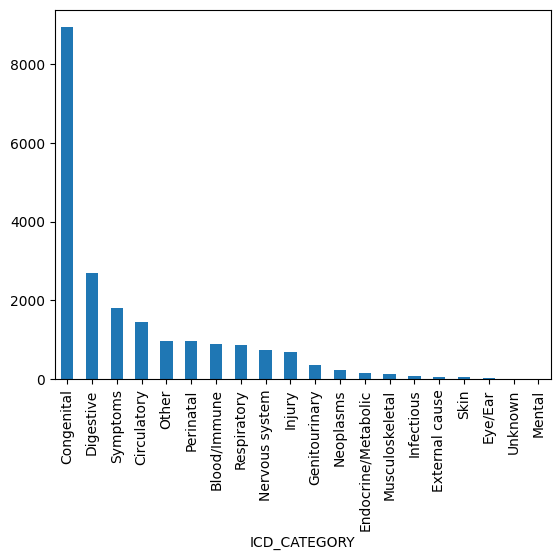

In [19]:
df["ICD_CATEGORY"].value_counts().plot(kind="bar")

Target variable : LOS

In [20]:
icustays = pd.read_csv("../paediatric-intensive-care-database-1.1.0/ICUSTAYS.csv")

print("ICUSTAYS shape:", icustays.shape)
print(icustays[["SUBJECT_ID", "HADM_ID", "LOS"]].head())

ICUSTAYS shape: (13941, 11)
   SUBJECT_ID  HADM_ID     LOS
0          26   100000  4.6167
1          28   100001  9.1771
2          29   100002  7.7326
3          30   100003  4.4132
4          31   100004  1.7479


In [21]:
#Step 8 — Merge ICUSTAYS LOS into Your Dataset
icustays_los = (
    icustays.groupby(["SUBJECT_ID", "HADM_ID"], as_index=False)["LOS"]
    .max()
)

df = df.merge(
    icustays_los,
    on=["SUBJECT_ID", "HADM_ID"],
    how="left"
)

print("After ICUSTAYS merge:", df.shape)
print(df[["SUBJECT_ID", "HADM_ID", "LOS"]].head())

After ICUSTAYS merge: (21225, 39)
   SUBJECT_ID  HADM_ID     LOS
0           4   102191  0.5215
1           4   102191  0.5215
2           4   102191  0.5215
3           4   102191  0.5215
4          37   102040  0.7535


In [18]:
df.head()

,SUBJECT_ID,HADM_ID,VISIT_ID,MONITORTIME,SV1_min,SV1_max,SV1_mean,SV1_median,SV2_min,SV2_max,...,SV7_max,SV7_mean,SV7_median,HOSPITAL_EXPIRE_FLAG,ICD10_CODE_CN,DIAGNOSIS,ICD10_CODE,TITLE,ICD_CATEGORY,LOS
0,4,102191,1,1981-09-25 18:40:00,67.0,95.0,77.461538,74.0,68.0,97.0,...,100.0,100.000000,100.0,0,K56.202,肠扭转,K56.2,Volvulus,Digestive,0.5215
1,4,102191,1,1981-09-25 19:45:00,73.0,92.0,80.846154,82.0,74.0,92.0,...,100.0,100.000000,100.0,0,K56.202,肠扭转,K56.2,Volvulus,Digestive,0.5215
2,4,102191,1,1981-09-25 20:50:00,70.0,116.0,91.461538,86.0,10.0,99.0,...,100.0,100.000000,100.0,0,K56.202,肠扭转,K56.2,Volvulus,Digestive,0.5215
3,4,102191,1,1981-09-25 21:55:00,83.0,95.0,88.000000,86.0,83.0,99.0,...,100.0,94.600000,100.0,0,K56.202,肠扭转,K56.2,Volvulus,Digestive,0.5215
4,37,102040,1,2071-08-12 11:00:00,70.0,99.0,84.928571,84.0,71.0,100.0,...,100.0,99.538462,100.0,0,K83.502,胆总管囊肿,K83.5,Biliary cyst,Digestive,0.7535


In [22]:
#Step 9 — Create Long ICU Stay Target
los_median = df["LOS"].median(skipna=True)
print("Median LOS:", los_median)

df["LONG_ICU_STAY"] = np.where(df["LOS"].notna() & (df["LOS"] > los_median), 1, 0)

print(df["LONG_ICU_STAY"].value_counts(dropna=False))

Median LOS: 1.0701
LONG_ICU_STAY
0    10617
1    10608
Name: count, dtype: int64


Target variable : HIGH_PAIN

In [23]:
# Step 10 — Load D_ITEMS and CHARTEVENTS for Pain Extraction
d_items = pd.read_csv("../paediatric-intensive-care-database-1.1.0/D_ITEMS.csv")
chartevents = pd.read_csv("../paediatric-intensive-care-database-1.1.0/CHARTEVENTS.csv")

print("D_ITEMS shape:", d_items.shape)
print("CHARTEVENTS shape:", chartevents.shape)

D_ITEMS shape: (466, 7)
CHARTEVENTS shape: (2278978, 10)


In [24]:
# Finding pain-related ITEMIDs in D_ITEMS (converting to numeric to avoid issues with string comparisons)
d_items["ITEMID"] = pd.to_numeric(d_items["ITEMID"], errors="coerce")
chartevents["ITEMID"] = pd.to_numeric(chartevents["ITEMID"], errors="coerce")

pain_items = d_items[
    d_items["LABEL"].astype(str).str.contains("pain", case=False, na=False)
].copy()

print("Pain-related ITEMIDs:")
print(pain_items[["ITEMID", "LABEL"]])

Pain-related ITEMIDs:
    ITEMID       LABEL
10  1012.0  Pain Score


In [25]:
#Step 12 — Extract Pain Rows from CHARTEVENTS
pain_itemids = pain_items["ITEMID"].dropna().astype(int).unique().tolist()

pain_events = chartevents[
    chartevents["ITEMID"].isin(pain_itemids)
].copy()

print("Pain ITEMIDs:", pain_itemids)


print("Pain events shape:", pain_events.shape)
print(pain_events[["SUBJECT_ID", "HADM_ID", "ITEMID", "VALUE", "VALUENUM"]].head())

Pain ITEMIDs: [1012]
Pain events shape: (6153, 10)
     SUBJECT_ID  HADM_ID  ITEMID  VALUE  VALUENUM
112       13097   113589    1012    0.0       0.0
122       12706   113176    1012    0.0       0.0
146       13097   113589    1012    0.0       0.0
582       12505   112951    1012    0.0       0.0
873        9908   110120    1012    0.0       0.0


In [26]:
# Step 13 — Build Pain Score Per Admission
# Keep only valid numeric pain scores
pain_events = pain_events[pain_events["VALUENUM"].notna()].copy()

pain_score_adm = (
    pain_events.groupby(["SUBJECT_ID", "HADM_ID"], as_index=False)["VALUENUM"]
    .mean()
    .rename(columns={"VALUENUM": "PAIN_SCORE"})
)

print("Pain score per admission shape:", pain_score_adm.shape)
print(pain_score_adm.head())

Pain score per admission shape: (3380, 3)
   SUBJECT_ID  HADM_ID  PAIN_SCORE
0        1187   101274         0.0
1        1199   101285         2.0
2        1254   101247         1.0
3        1255   101249         0.0
4        1273   101265         2.0


In [27]:
# Merge primary diagnosis into the main dataframe

df = df.merge(
    pain_score_adm,
    on=["SUBJECT_ID", "HADM_ID"],
    how="left"
)

print("After pain merge:", df.shape)
print(df[["SUBJECT_ID", "HADM_ID", "PAIN_SCORE"]].head())

After pain merge: (21225, 41)
   SUBJECT_ID  HADM_ID  PAIN_SCORE
0           4   102191         NaN
1           4   102191         NaN
2           4   102191         NaN
3           4   102191         NaN
4          37   102040         NaN


In [25]:
df.head()

,SUBJECT_ID,HADM_ID,VISIT_ID,MONITORTIME,SV1_min,SV1_max,SV1_mean,SV1_median,SV2_min,SV2_max,...,SV7_median,HOSPITAL_EXPIRE_FLAG,ICD10_CODE_CN,DIAGNOSIS,ICD10_CODE,TITLE,ICD_CATEGORY,LOS,LONG_ICU_STAY,PAIN_SCORE
0,4,102191,1,1981-09-25 18:40:00,67.0,95.0,77.461538,74.0,68.0,97.0,...,100.0,0,K56.202,肠扭转,K56.2,Volvulus,Digestive,0.5215,0,NaN
1,4,102191,1,1981-09-25 19:45:00,73.0,92.0,80.846154,82.0,74.0,92.0,...,100.0,0,K56.202,肠扭转,K56.2,Volvulus,Digestive,0.5215,0,NaN
2,4,102191,1,1981-09-25 20:50:00,70.0,116.0,91.461538,86.0,10.0,99.0,...,100.0,0,K56.202,肠扭转,K56.2,Volvulus,Digestive,0.5215,0,NaN
3,4,102191,1,1981-09-25 21:55:00,83.0,95.0,88.000000,86.0,83.0,99.0,...,100.0,0,K56.202,肠扭转,K56.2,Volvulus,Digestive,0.5215,0,NaN
4,37,102040,1,2071-08-12 11:00:00,70.0,99.0,84.928571,84.0,71.0,100.0,...,100.0,0,K83.502,胆总管囊肿,K83.5,Biliary cyst,Digestive,0.7535,0,NaN


In [28]:
print(df["PAIN_SCORE"].max())
print(df["PAIN_SCORE"].min())

25.0
0.0


In [29]:
# Step 15 — Create High Pain Target
# HIGH_PAIN = 1 if PAIN_SCORE >= 5
df["HIGH_PAIN"] = np.where(df["PAIN_SCORE"].notna() & (df["PAIN_SCORE"] >= 5), 1, 0)

print(df["HIGH_PAIN"].value_counts(dropna=False))


HIGH_PAIN
0    21215
1       10
Name: count, dtype: int64


In [28]:
df.head()

,SUBJECT_ID,HADM_ID,VISIT_ID,MONITORTIME,SV1_min,SV1_max,SV1_mean,SV1_median,SV2_min,SV2_max,...,HOSPITAL_EXPIRE_FLAG,ICD10_CODE_CN,DIAGNOSIS,ICD10_CODE,TITLE,ICD_CATEGORY,LOS,LONG_ICU_STAY,PAIN_SCORE,HIGH_PAIN
0,4,102191,1,1981-09-25 18:40:00,67.0,95.0,77.461538,74.0,68.0,97.0,...,0,K56.202,肠扭转,K56.2,Volvulus,Digestive,0.5215,0,NaN,0
1,4,102191,1,1981-09-25 19:45:00,73.0,92.0,80.846154,82.0,74.0,92.0,...,0,K56.202,肠扭转,K56.2,Volvulus,Digestive,0.5215,0,NaN,0
2,4,102191,1,1981-09-25 20:50:00,70.0,116.0,91.461538,86.0,10.0,99.0,...,0,K56.202,肠扭转,K56.2,Volvulus,Digestive,0.5215,0,NaN,0
3,4,102191,1,1981-09-25 21:55:00,83.0,95.0,88.000000,86.0,83.0,99.0,...,0,K56.202,肠扭转,K56.2,Volvulus,Digestive,0.5215,0,NaN,0
4,37,102040,1,2071-08-12 11:00:00,70.0,99.0,84.928571,84.0,71.0,100.0,...,0,K83.502,胆总管囊肿,K83.5,Biliary cyst,Digestive,0.7535,0,NaN,0


Target variable : SEVERE_ANEMIA

In [30]:
labevents = pd.read_csv("../paediatric-intensive-care-database-1.1.0/LABEVENTS.csv")
d_labitems = pd.read_csv("../paediatric-intensive-care-database-1.1.0/D_LABITEMS.csv")

print("LABEVENTS:", labevents.shape)
print("D_LABITEMS:", d_labitems.shape)

LABEVENTS: (10094117, 9)
D_LABITEMS: (832, 7)


In [31]:
#df.columns = [c.strip() for c in df.columns]
labevents.columns = [c.strip() for c in labevents.columns]
d_labitems.columns = [c.strip() for c in d_labitems.columns]

In [32]:
df["MONITORTIME"] = pd.to_datetime(df["MONITORTIME"], errors="coerce")

labevents["CHARTTIME"] = pd.to_datetime(
    labevents["CHARTTIME"],
    errors="coerce"
)

In [33]:
labevents["VALUENUM"] = pd.to_numeric(
    labevents["VALUENUM"],
    errors="coerce"
)

In [34]:
labevents = labevents.dropna(subset=["VALUENUM"])

In [35]:
# Step 7 — Identify Hemoglobin ITEMID
hb_items = d_labitems[
    d_labitems["LABEL"].astype(str).str.contains("hemoglobin", case=False)
]

print("Hemoglobin ITEMIDs:")
print(hb_items[["ITEMID","LABEL"]])

Hemoglobin ITEMIDs:
     ITEMID                         LABEL
63     5099                    Hemoglobin
95     5173  Methemoglobin reduction test
132    5219             Carboxyhemoglobin
140    5228                 Methemoglobin
165    5257                    Hemoglobin
297    5628              % Hemoglobin A1c
350    6070              % Hemoglobin A1c
436    6289                 Hemoglobin A2


In [36]:
# Step 8 — Extract Hemoglobin ITEMIDs
hb_itemids = (
    hb_items["ITEMID"]
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

print("Selected Hemoglobin ITEMIDs:", hb_itemids)


Selected Hemoglobin ITEMIDs: [5099, 5173, 5219, 5228, 5257, 5628, 6070, 6289]


In [37]:
# Step 9 — Extract Hemoglobin lab events
hb_events = labevents[
    labevents["ITEMID"].isin(hb_itemids)
].copy()

hb_events = hb_events[
    ["SUBJECT_ID","HADM_ID","CHARTTIME","VALUENUM"]
]

hb_events = hb_events.rename(
    columns={"VALUENUM":"HEMOGLOBIN"}
)

print("Hemoglobin events:", hb_events.shape)
print(hb_events.head())

Hemoglobin events: (703668, 4)
    SUBJECT_ID  HADM_ID           CHARTTIME  HEMOGLOBIN
9         3665   103732 2077-10-25 09:23:38        15.3
21        3665   103732 2077-10-25 09:23:38         0.7
28        3665   103732 2077-10-25 09:23:38         1.2
37        3665   103732 2077-10-22 16:58:18        14.5
58        3665   103732 2077-10-22 16:58:18         0.4


In [38]:
# Step 10 — Create hourly time window
hb_events["HOUR"] = hb_events["CHARTTIME"].dt.floor("H")

/var/folders/6c/h_2qq_495412tl4y7hpdmk5c0000gn/T/ipykernel_28728/3023048398.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hb_events["HOUR"] = hb_events["CHARTTIME"].dt.floor("H")


In [39]:
# Step 11 — Aggregate hourly hemoglobin
hb_hourly = (
    hb_events.groupby(
        ["SUBJECT_ID","HADM_ID","HOUR"],
        as_index=False
    )
    .agg(
        HB_MEAN=("HEMOGLOBIN","mean"),
        HB_MIN=("HEMOGLOBIN","min"),
        HB_MAX=("HEMOGLOBIN","max")
    )
)

print("Hourly hemoglobin:", hb_hourly.shape)
print(hb_hourly.head())

Hourly hemoglobin: (278286, 6)
   SUBJECT_ID  HADM_ID                HOUR     HB_MEAN  HB_MIN  HB_MAX
0           4   102191 2081-09-25 13:00:00   47.733333     0.0   142.0
1           4   102191 2081-09-25 14:00:00  134.000000   134.0   134.0
2           4   102191 2081-09-25 21:00:00   40.233333     0.8   119.0
3           4   102191 2081-09-25 23:00:00   68.300000     0.4   136.0
4           4   102191 2081-09-26 00:00:00   46.033333     1.3   135.0


Step 12 — Define anemia target

Clinical rule:

Hemoglobin	Interpretation

= 10 | normal |
< 10 | anemia |
< 7 | severe anemia |

In [40]:
hb_hourly["ANEMIA_FLAG"] = np.where(
    hb_hourly["HB_MIN"] < 10,
    1,
    0
)

In [41]:
print("Anemia counts:")
print(hb_hourly["ANEMIA_FLAG"].value_counts())


Anemia counts:
ANEMIA_FLAG
1    192747
0     85539
Name: count, dtype: int64


In [42]:
df["HOUR"] = df["MONITORTIME"].dt.floor("H")

/var/folders/6c/h_2qq_495412tl4y7hpdmk5c0000gn/T/ipykernel_28728/634922793.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["HOUR"] = df["MONITORTIME"].dt.floor("H")


In [44]:
df = df.merge(
    hb_hourly[
        [
            "SUBJECT_ID",
            "HADM_ID",
            "HOUR",
            "HB_MEAN",
            "HB_MIN",
            "HB_MAX",
            "ANEMIA_FLAG",
        ]
    ],
    on=["SUBJECT_ID","HADM_ID","HOUR"],
    how="left"
)

print("Merged dataframe:", df.shape)

Merged dataframe: (21225, 51)


In [45]:
df.head()

,SUBJECT_ID,HADM_ID,VISIT_ID,MONITORTIME,SV1_min,SV1_max,SV1_mean,SV1_median,SV2_min,SV2_max,...,HIGH_PAIN,HOUR,HB_MEAN_x,HB_MIN_x,HB_MAX_x,ANEMIA_FLAG_x,HB_MEAN_y,HB_MIN_y,HB_MAX_y,ANEMIA_FLAG_y
0,4,102191,1,1981-09-25 18:40:00,67.0,95.0,77.461538,74.0,68.0,97.0,...,0,1981-09-25 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4,102191,1,1981-09-25 19:45:00,73.0,92.0,80.846154,82.0,74.0,92.0,...,0,1981-09-25 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,102191,1,1981-09-25 20:50:00,70.0,116.0,91.461538,86.0,10.0,99.0,...,0,1981-09-25 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,102191,1,1981-09-25 21:55:00,83.0,95.0,88.000000,86.0,83.0,99.0,...,0,1981-09-25 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,37,102040,1,2071-08-12 11:00:00,70.0,99.0,84.928571,84.0,71.0,100.0,...,0,2071-08-12 11:00:00,40.866667,1.2,120.0,1.0,40.866667,1.2,120.0,1.0


In [46]:
df.to_csv("output/final_merged_sv_targets.csv", index=False)
print("Saved: final_merged_sv_targets.csv")

Saved: final_merged_sv_targets.csv


In [47]:
dfinal = pd.read_csv("output/final_merged_sv_targets.csv")
dfinal.head()

,SUBJECT_ID,HADM_ID,VISIT_ID,MONITORTIME,SV1_min,SV1_max,SV1_mean,SV1_median,SV2_min,SV2_max,...,HIGH_PAIN,HOUR,HB_MEAN_x,HB_MIN_x,HB_MAX_x,ANEMIA_FLAG_x,HB_MEAN_y,HB_MIN_y,HB_MAX_y,ANEMIA_FLAG_y
0,4,102191,1,1981-09-25 18:40:00,67.0,95.0,77.461538,74.0,68.0,97.0,...,0,1981-09-25 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4,102191,1,1981-09-25 19:45:00,73.0,92.0,80.846154,82.0,74.0,92.0,...,0,1981-09-25 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,102191,1,1981-09-25 20:50:00,70.0,116.0,91.461538,86.0,10.0,99.0,...,0,1981-09-25 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,102191,1,1981-09-25 21:55:00,83.0,95.0,88.000000,86.0,83.0,99.0,...,0,1981-09-25 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,37,102040,1,2071-08-12 11:00:00,70.0,99.0,84.928571,84.0,71.0,100.0,...,0,2071-08-12 11:00:00,40.866667,1.2,120.0,1.0,40.866667,1.2,120.0,1.0


Plots

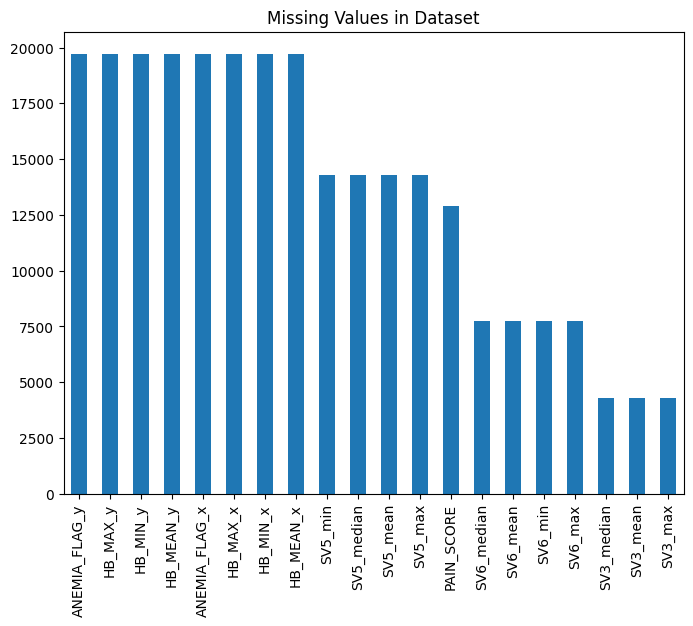

In [48]:
missing = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(8,6))

missing.head(20).plot(kind='bar')

plt.title("Missing Values in Dataset")

plt.show()

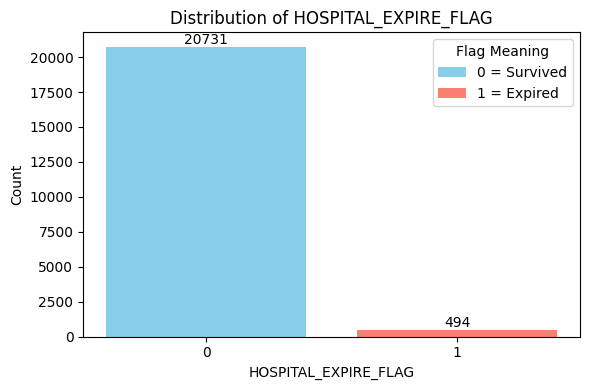

In [49]:
from matplotlib.patches import Patch

mortality_counts = df["HOSPITAL_EXPIRE_FLAG"].value_counts(dropna=False).sort_index()

plt.figure(figsize=(6,4))
bars = plt.bar(
    mortality_counts.index.astype(str),
    mortality_counts.values,
    color=["skyblue", "salmon"]
)

plt.title("Distribution of HOSPITAL_EXPIRE_FLAG")
plt.xlabel("HOSPITAL_EXPIRE_FLAG")
plt.ylabel("Count")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

legend_elements = [
    Patch(facecolor="skyblue", label="0 = Survived"),
    Patch(facecolor="salmon", label="1 = Expired")
]

plt.legend(handles=legend_elements, title="Flag Meaning")

plt.tight_layout()
plt.show()


/var/folders/6c/h_2qq_495412tl4y7hpdmk5c0000gn/T/ipykernel_28728/507028603.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([surv, died], labels=["Survived", "Expired"])


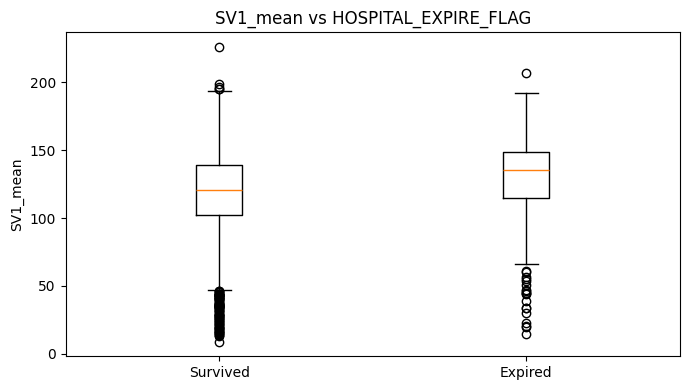

In [50]:
plot_col = "SV1_mean"

if plot_col in df.columns:
    surv = df[df["HOSPITAL_EXPIRE_FLAG"] == 0][plot_col].dropna()
    died = df[df["HOSPITAL_EXPIRE_FLAG"] == 1][plot_col].dropna()

    plt.figure(figsize=(7,4))
    plt.boxplot([surv, died], labels=["Survived", "Expired"])
    plt.title(f"{plot_col} vs HOSPITAL_EXPIRE_FLAG")
    plt.ylabel(plot_col)
    plt.tight_layout()
    plt.show()

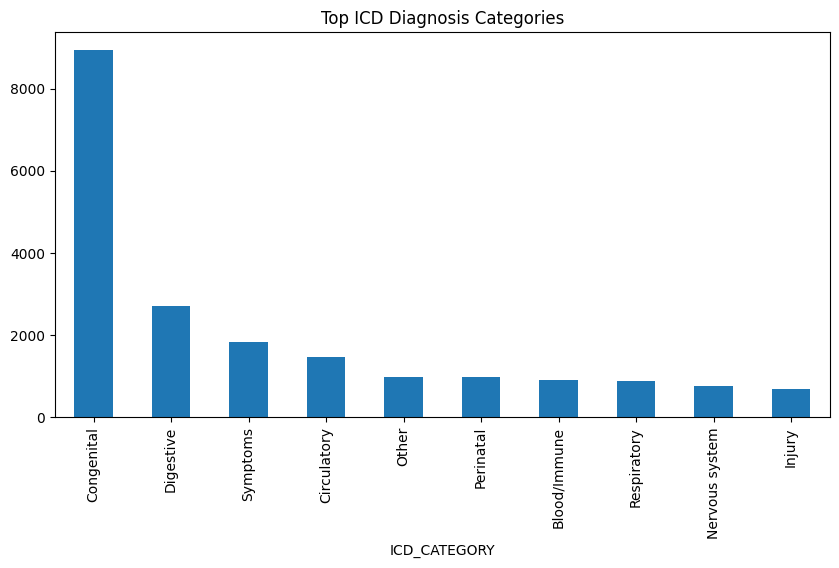

In [51]:
plt.figure(figsize=(10,5))

df['ICD_CATEGORY'].value_counts().head(10).plot(kind='bar')

plt.title("Top ICD Diagnosis Categories")

plt.show()

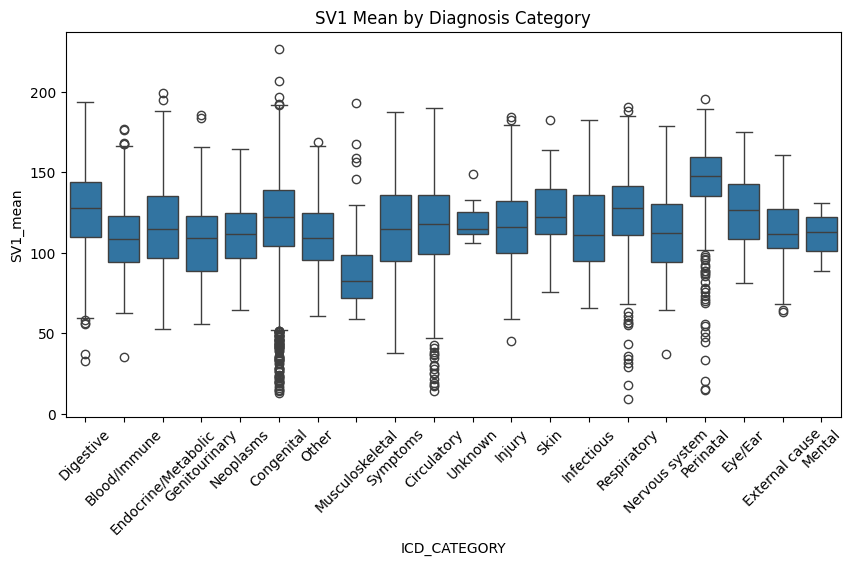

In [52]:
plt.figure(figsize=(10,5))

sns.boxplot(x='ICD_CATEGORY', y='SV1_mean', data=df)

plt.xticks(rotation=45)

plt.title("SV1 Mean by Diagnosis Category")

plt.show()

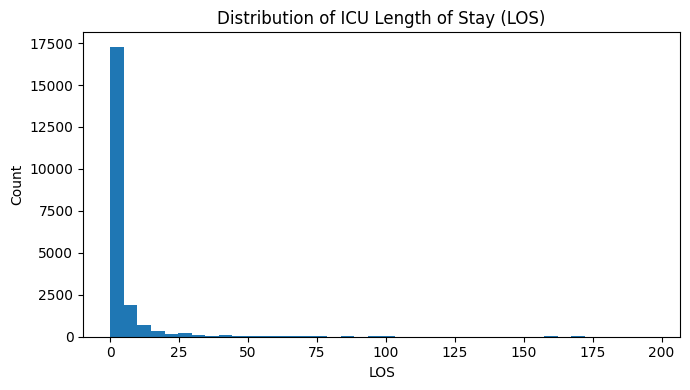

In [53]:
plt.figure(figsize=(7,4))
plt.hist(df["LOS"].dropna(), bins=40)
plt.title("Distribution of ICU Length of Stay (LOS)")
plt.xlabel("LOS")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [54]:
plot_col = "SV1_range"

if plot_col in df.columns:
    short_stay = df[df["LONG_ICU_STAY"] == 0][plot_col].dropna()
    long_stay = df[df["LONG_ICU_STAY"] == 1][plot_col].dropna()

    plt.figure(figsize=(7,4))
    plt.boxplot([short_stay, long_stay], labels=["Short ICU Stay", "Long ICU Stay"])
    plt.title(f"{plot_col} vs LONG_ICU_STAY")
    plt.ylabel(plot_col)
    plt.tight_layout()
    plt.show()

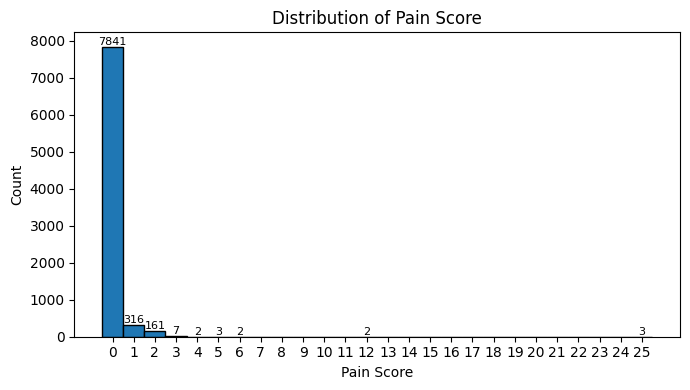

In [57]:
plt.figure(figsize=(7,4))

# Remove NaNs and convert to int
pain = df["PAIN_SCORE"].dropna().astype(int)

# Create bins for discrete values
bins = np.arange(pain.min(), pain.max() + 2) - 0.5

counts, bins, patches = plt.hist(pain, bins=bins, edgecolor='black')

plt.title("Distribution of Pain Score")
plt.xlabel("Pain Score")
plt.ylabel("Count")

# Set x-axis ticks correctly
plt.xticks(np.arange(pain.min(), pain.max() + 1))

# Add values on bars
for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width()/2,
            count,
            f"{int(count)}",
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.tight_layout()
plt.show()

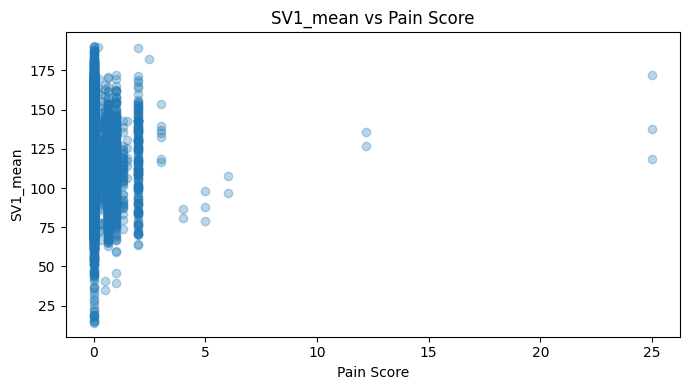

In [79]:
if "PAIN_SCORE" in df.columns and "SV1_mean" in df.columns:
    temp = df[["PAIN_SCORE", "SV1_mean"]].dropna()

    plt.figure(figsize=(7,4))
    plt.scatter(temp["PAIN_SCORE"], temp["SV1_mean"], alpha=0.3)
    plt.title("SV1_mean vs Pain Score")
    plt.xlabel("Pain Score")
    plt.ylabel("SV1_mean")
    plt.tight_layout()
    plt.show()

In [76]:
sv_mean_cols = [c for c in df.columns if c.startswith("SV") and c.endswith("_mean")]
sv_range_cols = []

for i in range(1, 8):
    max_col = f"SV{i}_max"
    min_col = f"SV{i}_min"
    range_col = f"SV{i}_range"
    if max_col in df.columns and min_col in df.columns:
        df[range_col] = df[max_col] - df[min_col]
        sv_range_cols.append(range_col)

print("SV mean columns:", sv_mean_cols)
print("SV range columns:", sv_range_cols)

SV mean columns: ['SV1_mean', 'SV2_mean', 'SV3_mean', 'SV4_mean', 'SV5_mean', 'SV6_mean', 'SV7_mean']
SV range columns: ['SV1_range', 'SV2_range', 'SV3_range', 'SV4_range', 'SV5_range', 'SV6_range', 'SV7_range']


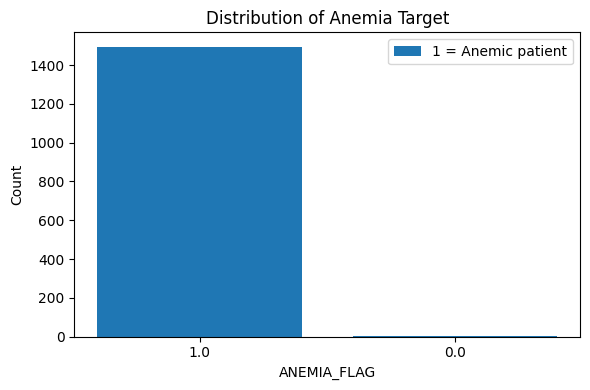

In [50]:
counts = df["ANEMIA_FLAG"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Distribution of Anemia Target")
plt.xlabel("ANEMIA_FLAG")
plt.ylabel("Count")
plt.tight_layout()
plt.legend(["1 = Anemic patient"])
plt.show()

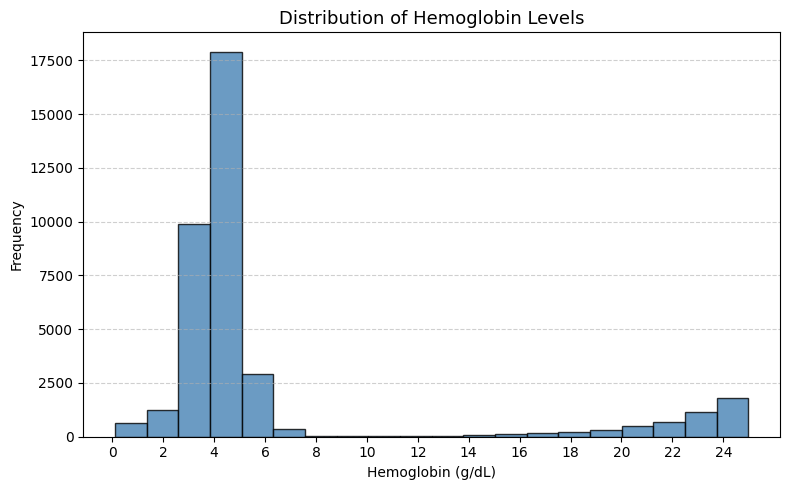

In [59]:

# Remove unrealistic values
hb_clean = hb_hourly["HB_MEAN"].dropna()
hb_clean = hb_clean[(hb_clean > 0) & (hb_clean < 25)]

plt.figure(figsize=(8,5))

counts, bins, patches = plt.hist(
    hb_clean,
    bins=20,
    color="steelblue",
    edgecolor="black",
    alpha=0.8
)


plt.title("Distribution of Hemoglobin Levels", fontsize=13)
plt.xlabel("Hemoglobin (g/dL)")
plt.ylabel("Frequency")

# Better x-axis ticks
plt.xticks(np.arange(0, 26, 2))

# Grid for readability
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

/var/folders/6c/h_2qq_495412tl4y7hpdmk5c0000gn/T/ipykernel_20362/1236761073.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal, anemia], labels=["Normal","Anemia"])


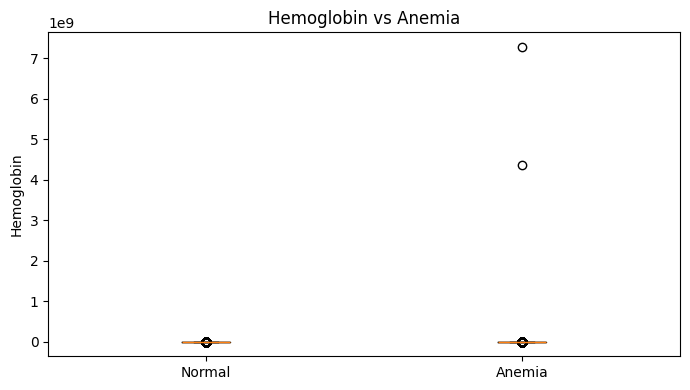

In [156]:
normal = hb_hourly[hb_hourly["ANEMIA_FLAG"]==0]["HB_MEAN"]
anemia = hb_hourly[hb_hourly["ANEMIA_FLAG"]==1]["HB_MEAN"]

plt.figure(figsize=(7,4))
plt.boxplot([normal, anemia], labels=["Normal","Anemia"])

plt.title("Hemoglobin vs Anemia")
plt.ylabel("Hemoglobin")

plt.tight_layout()
plt.show()

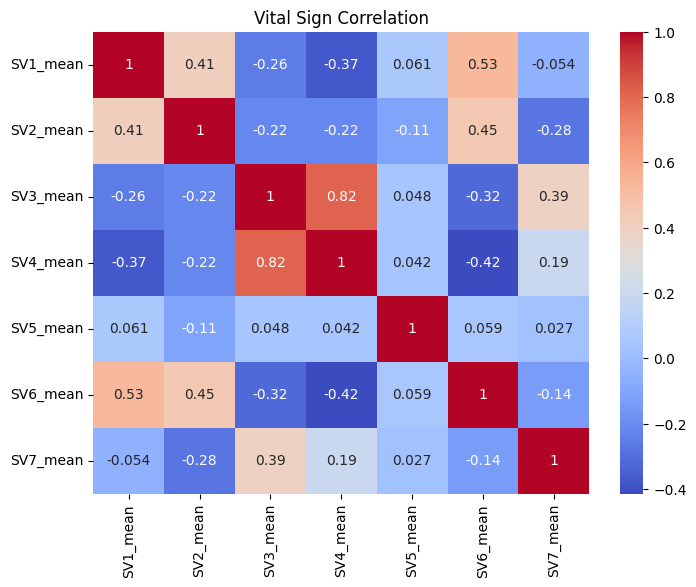

In [85]:
vital_cols = [col for col in df.columns if "SV" in col and "mean" in col]

plt.figure(figsize=(8,6))

sns.heatmap(df[vital_cols].corr(), annot=True, cmap='coolwarm')

plt.title("Vital Sign Correlation")

plt.show()

In [60]:
target_variables = [
    "HOSPITAL_EXPIRE_FLAG",
    "ICD_CATEGORY",
    "LOS",
    "PAIN_SCORE",
    "HR_ABNORMAL_FLAG",
    "ANEMIA_FLAG",
]

print(target_variables)

['HOSPITAL_EXPIRE_FLAG', 'ICD_CATEGORY', 'LOS', 'PAIN_SCORE', 'HR_ABNORMAL_FLAG', 'ANEMIA_FLAG']


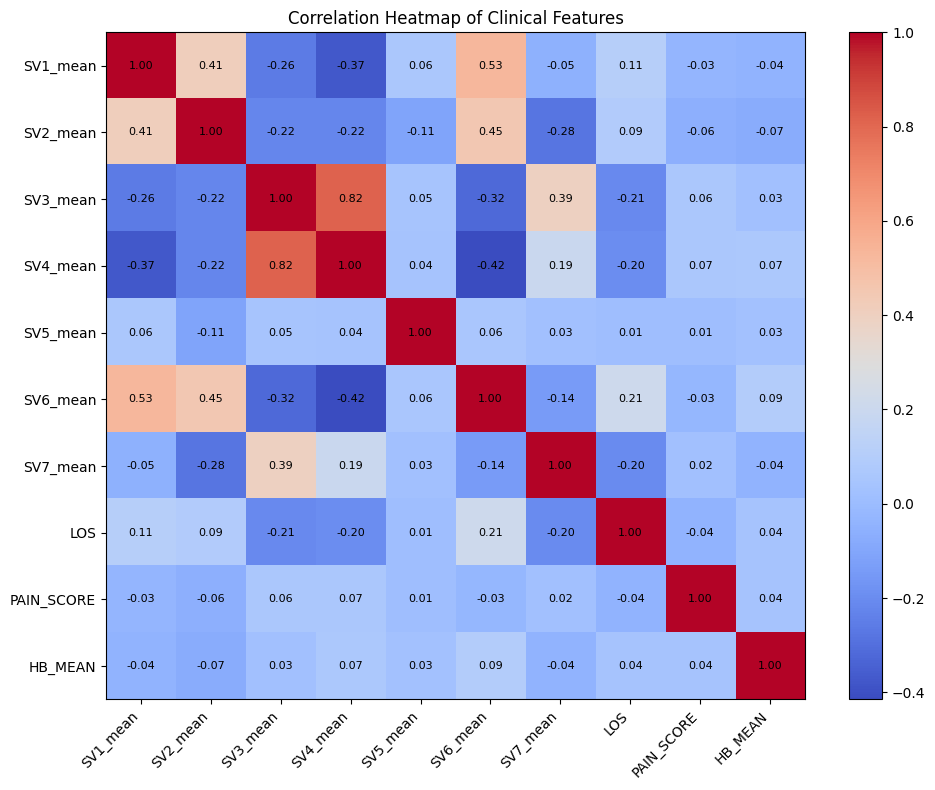

In [62]:

cols = [
    "SV1_mean", "SV2_mean", "SV3_mean", "SV4_mean", "SV5_mean", "SV6_mean", "SV7_mean",
    "LOS", "PAIN_SCORE", "HB_MEAN"
]

corr_cols = [c for c in cols if c in df.columns]
corr_df = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
im = plt.imshow(corr_df, cmap="coolwarm", aspect="auto")
plt.colorbar(im)

plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_df.columns)), corr_df.columns)

for i in range(len(corr_df.index)):
    for j in range(len(corr_df.columns)):
        plt.text(j, i, f"{corr_df.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Correlation Heatmap of Clinical Features")
plt.tight_layout()
plt.show()

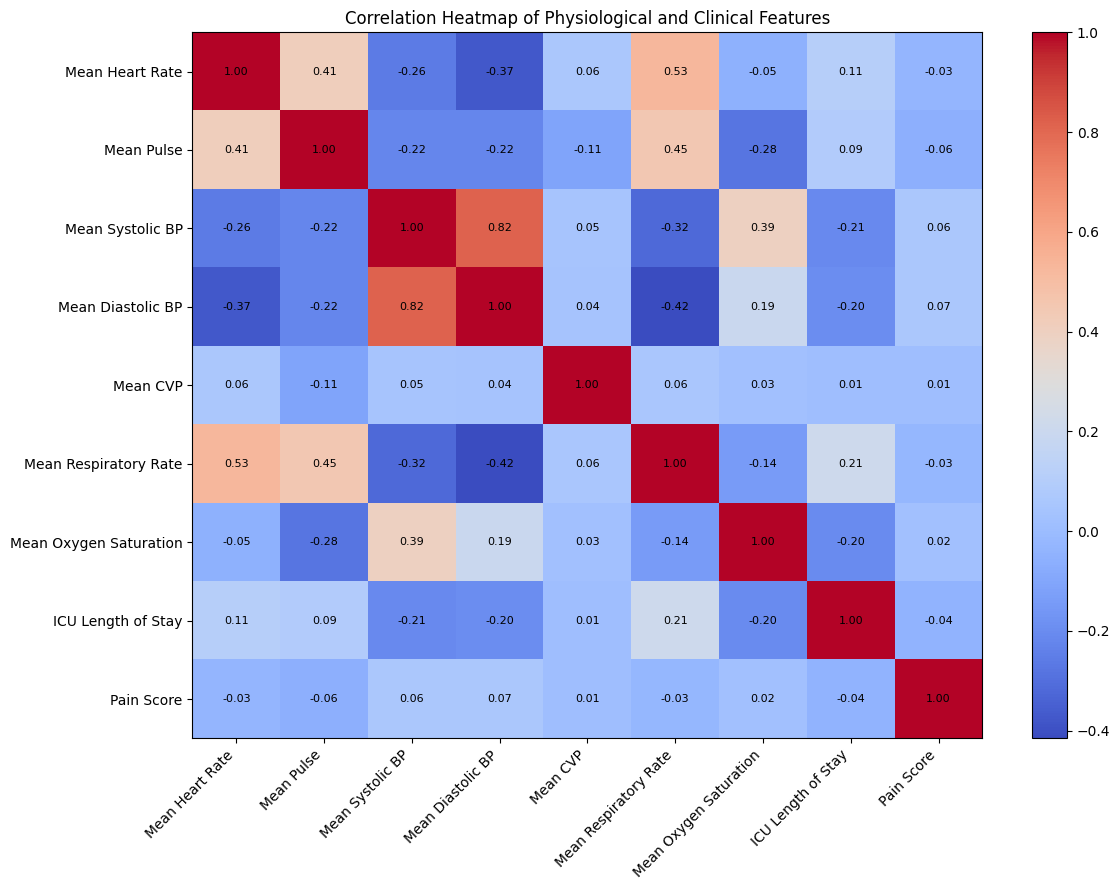

In [73]:
import matplotlib.pyplot as plt

# Original columns
cols = [
    "SV1_mean", "SV2_mean", "SV3_mean", "SV4_mean",
    "SV5_mean", "SV6_mean", "SV7_mean",
    "LOS", "PAIN_SCORE", "HB_MEAN"
]

# Readable labels for IEEE paper
label_mapping = {
    "SV1_mean": "Mean Heart Rate",
    "SV2_mean": "Mean Pulse",
    "SV3_mean": "Mean Systolic BP",
    "SV4_mean": "Mean Diastolic BP",
    "SV5_mean": "Mean CVP",
    "SV6_mean": "Mean Respiratory Rate",
    "SV7_mean": "Mean Oxygen Saturation",
    "LOS": "ICU Length of Stay",
    "PAIN_SCORE": "Pain Score",
    "HB_MEAN": "Mean Hemoglobin"
}

# Filter available columns
corr_cols = [c for c in cols if c in df.columns]

# Correlation matrix
corr_df = df[corr_cols].corr(numeric_only=True)

# Rename rows and columns for display
corr_df.rename(index=label_mapping, columns=label_mapping, inplace=True)

# Plot
plt.figure(figsize=(12, 9))

im = plt.imshow(corr_df, cmap="coolwarm", aspect="auto")
plt.colorbar(im)

plt.xticks(
    range(len(corr_df.columns)),
    corr_df.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_df.index)),
    corr_df.index
)

# Add correlation values
for i in range(len(corr_df.index)):
    for j in range(len(corr_df.columns)):
        plt.text(
            j, i,
            f"{corr_df.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Heatmap of Physiological and Clinical Features")

plt.tight_layout()
plt.show()

/var/folders/6c/h_2qq_495412tl4y7hpdmk5c0000gn/T/ipykernel_25943/1162450679.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([survived, expired], labels=["Survived", "Expired"])


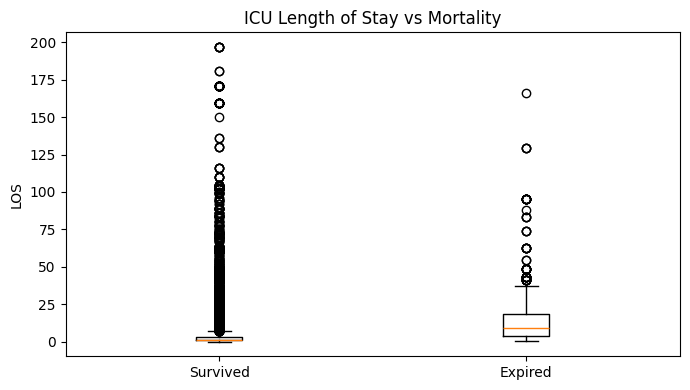

In [63]:

plot_df = df[["LOS", "HOSPITAL_EXPIRE_FLAG"]].dropna()

survived = plot_df[plot_df["HOSPITAL_EXPIRE_FLAG"] == 0]["LOS"]
expired = plot_df[plot_df["HOSPITAL_EXPIRE_FLAG"] == 1]["LOS"]

plt.figure(figsize=(7, 4))
plt.boxplot([survived, expired], labels=["Survived", "Expired"])

plt.title("ICU Length of Stay vs Mortality")
plt.ylabel("LOS")
plt.tight_layout()
plt.show()

/var/folders/6c/h_2qq_495412tl4y7hpdmk5c0000gn/T/ipykernel_25943/4151503836.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([survived, expired], labels=["Survived", "Expired"])


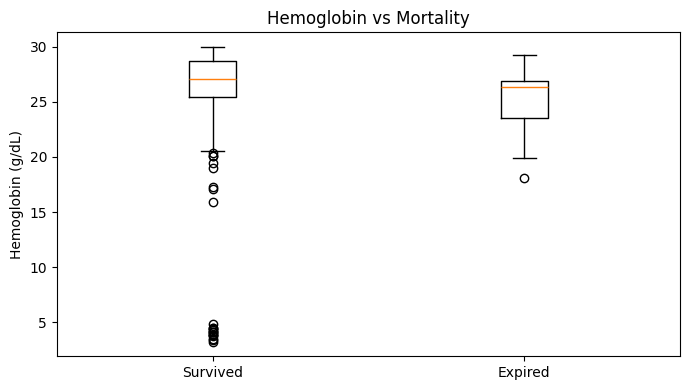

In [64]:

plot_df = df[["HB_MEAN", "HOSPITAL_EXPIRE_FLAG"]].dropna()

# optional cleaning to remove unrealistic values
plot_df = plot_df[(plot_df["HB_MEAN"] > 0) & (plot_df["HB_MEAN"] < 30)]

survived = plot_df[plot_df["HOSPITAL_EXPIRE_FLAG"] == 0]["HB_MEAN"]
expired = plot_df[plot_df["HOSPITAL_EXPIRE_FLAG"] == 1]["HB_MEAN"]

plt.figure(figsize=(7, 4))
plt.boxplot([survived, expired], labels=["Survived", "Expired"])

plt.title("Hemoglobin vs Mortality")
plt.ylabel("Hemoglobin (g/dL)")
plt.tight_layout()
plt.show()

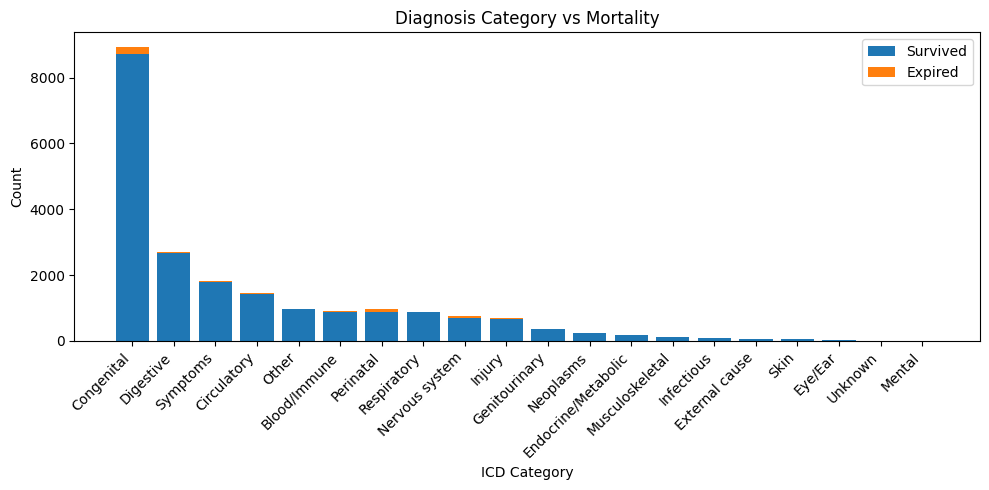

In [ ]:

plot_df = df[["ICD_CATEGORY", "HOSPITAL_EXPIRE_FLAG"]].dropna()

summary = plot_df.groupby(["ICD_CATEGORY", "HOSPITAL_EXPIRE_FLAG"]).size().unstack(fill_value=0)

summary = summary.sort_values(by=0, ascending=False)

x = np.arange(len(summary.index))
survived = summary[0] if 0 in summary.columns else np.zeros(len(summary))
expired = summary[1] if 1 in summary.columns else np.zeros(len(summary))

plt.figure(figsize=(10, 5))
plt.bar(x, survived, label="Survived")
plt.bar(x, expired, bottom=survived, label="Expired")

plt.xticks(x, summary.index, rotation=45, ha="right")
plt.ylabel("Count")
plt.xlabel("ICD Category")
plt.title("Diagnosis Category vs Mortality")
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/6c/h_2qq_495412tl4y7hpdmk5c0000gn/T/ipykernel_28728/2170686161.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if survived[i] > 0:
/var/folders/6c/h_2qq_495412tl4y7hpdmk5c0000gn/T/ipykernel_28728/2170686161.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i, survived[i]/2, f"{survived[i]:.1f}%", ha='center', color='black', fontsize=8)
/var/folders/6c/h_2qq_495412tl4y7hpdmk5c0000gn/T/ipykernel_28728/2170686161.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame beh

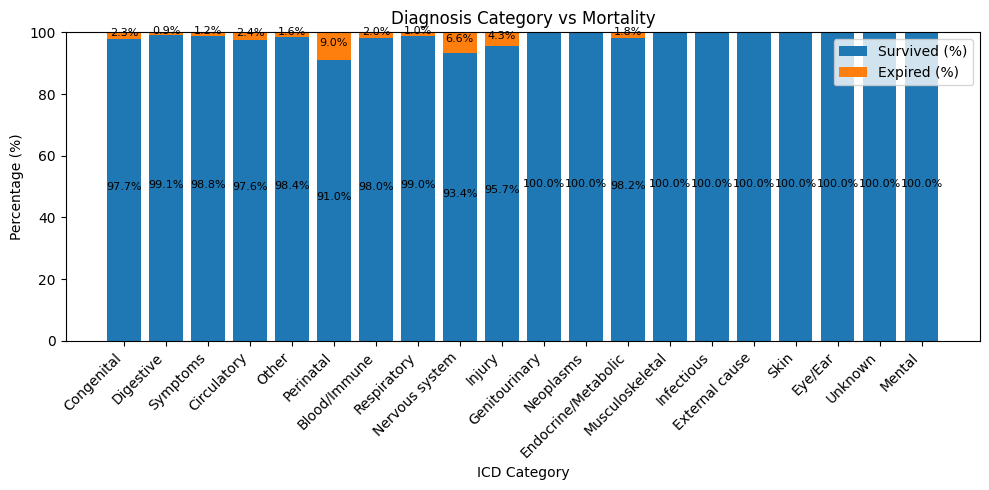

In [66]:
plot_df = df[["ICD_CATEGORY", "HOSPITAL_EXPIRE_FLAG"]].dropna()

# Count occurrences
summary = plot_df.groupby(["ICD_CATEGORY", "HOSPITAL_EXPIRE_FLAG"]).size().unstack(fill_value=0)

# Convert to percentage
summary_pct = summary.div(summary.sum(axis=1), axis=0) * 100
# Sort by total cases (optional, keeps your original behavior)
summary_pct = summary_pct.loc[summary.sum(axis=1).sort_values(ascending=False).index]

x = np.arange(len(summary_pct.index))

survived = summary_pct[0] if 0 in summary_pct.columns else np.zeros(len(summary_pct))
expired = summary_pct[1] if 1 in summary_pct.columns else np.zeros(len(summary_pct))

plt.figure(figsize=(10, 5))

plt.bar(x, survived, label="Survived (%)")
plt.bar(x, expired, bottom=survived, label="Expired (%)")

plt.xticks(x, summary_pct.index, rotation=45, ha="right")
plt.ylabel("Percentage (%)")
plt.xlabel("ICD Category")
plt.title("Diagnosis Category vs Mortality")

for i in range(len(x)):
    if survived[i] > 0:
        plt.text(i, survived[i]/2, f"{survived[i]:.1f}%", ha='center', color='black', fontsize=8)
    if expired[i] > 0:
        plt.text(i, survived[i] + expired[i]/2, f"{expired[i]:.1f}%", ha='center', color='black', fontsize=8)

plt.legend()
plt.tight_layout()
plt.show()

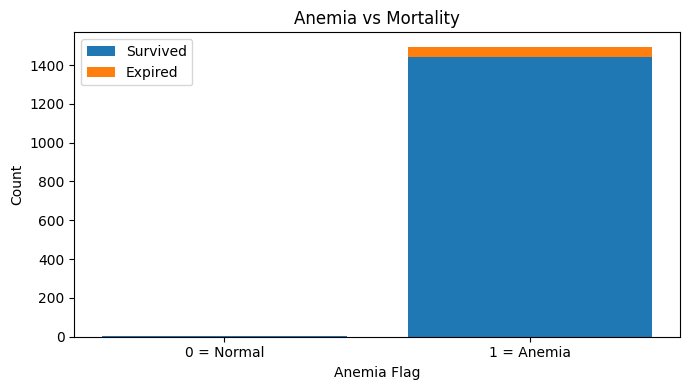

In [67]:

plot_df = df[["ANEMIA_FLAG", "HOSPITAL_EXPIRE_FLAG"]].dropna()

summary = plot_df.groupby(["ANEMIA_FLAG", "HOSPITAL_EXPIRE_FLAG"]).size().unstack(fill_value=0)

x = np.arange(len(summary.index))
survived = summary[0] if 0 in summary.columns else np.zeros(len(summary))
expired = summary[1] if 1 in summary.columns else np.zeros(len(summary))

labels = ["0 = Normal", "1 = Anemia"]

plt.figure(figsize=(7, 4))
plt.bar(x, survived, label="Survived")
plt.bar(x, expired, bottom=survived, label="Expired")

plt.xticks(x, labels[:len(summary.index)])
plt.ylabel("Count")
plt.xlabel("Anemia Flag")
plt.title("Anemia vs Mortality")
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/6c/h_2qq_495412tl4y7hpdmk5c0000gn/T/ipykernel_25943/1838702599.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([survived, expired], labels=["Survived", "Expired"])


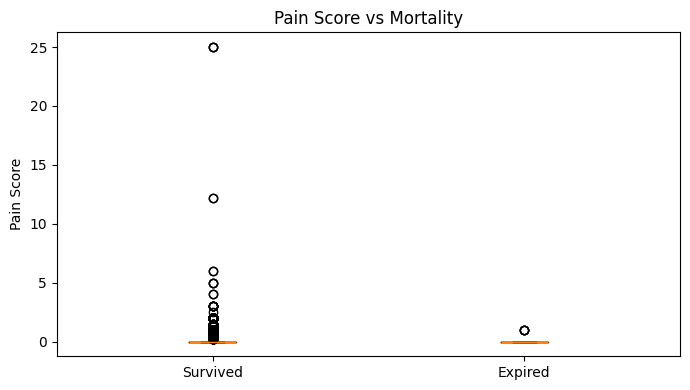

In [68]:

plot_df = df[["PAIN_SCORE", "HOSPITAL_EXPIRE_FLAG"]].dropna()

survived = plot_df[plot_df["HOSPITAL_EXPIRE_FLAG"] == 0]["PAIN_SCORE"]
expired = plot_df[plot_df["HOSPITAL_EXPIRE_FLAG"] == 1]["PAIN_SCORE"]

plt.figure(figsize=(7, 4))
plt.boxplot([survived, expired], labels=["Survived", "Expired"])

plt.title("Pain Score vs Mortality")
plt.ylabel("Pain Score")
plt.tight_layout()
plt.show()

Add patient analysis

In [67]:
df.groupby("SUBJECT_ID")["SV1_mean"].count().sort_values(ascending=False).head()

SUBJECT_ID
7664    33
4588    28
7532    27
4550    25
4421    23
Name: SV1_mean, dtype: int64

In [68]:

selected_subject = 7664

patient_df = df[df["SUBJECT_ID"] == selected_subject].copy()

patient_df["MONITORTIME"] = pd.to_datetime(patient_df["MONITORTIME"], errors="coerce")
patient_df = patient_df.dropna(subset=["MONITORTIME"])
patient_df = patient_df.sort_values("MONITORTIME")

print(patient_df[[
    "SUBJECT_ID", "HADM_ID", "VISIT_ID", "MONITORTIME",
    "SV1_mean", "SV3_mean", "SV4_mean", "SV6_mean", "SV7_mean"
]].head())

      SUBJECT_ID  HADM_ID  VISIT_ID         MONITORTIME    SV1_mean  SV3_mean  \
8591        7664   107724         1 1996-06-06 14:37:00  131.769231       NaN   
8592        7664   107724         1 1996-06-06 15:40:00  138.538462       NaN   
8593        7664   107724         1 1996-06-06 16:45:00  162.571429       NaN   
8594        7664   107724         1 1996-06-06 17:50:00  140.400000       NaN   
8595        7664   107724         1 1996-06-06 18:55:00  141.000000       NaN   

      SV4_mean  SV6_mean    SV7_mean  
8591       NaN       NaN   98.230769  
8592       NaN       NaN   96.250000  
8593       NaN       NaN   99.571429  
8594       NaN       NaN   99.600000  
8595       NaN       NaN  100.000000  


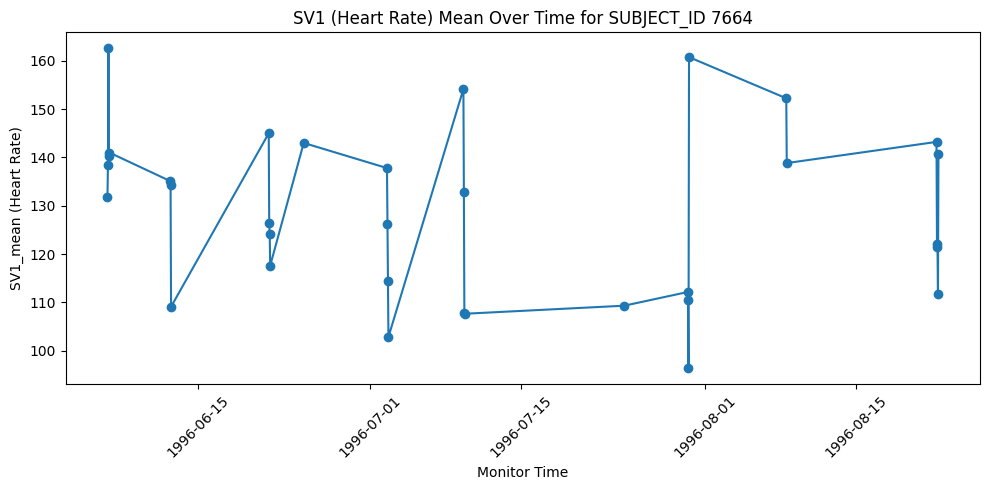

In [70]:
plt.figure(figsize=(10,5))
plt.plot(patient_df["MONITORTIME"], patient_df["SV1_mean"], marker="o")

plt.title("SV1 (Heart Rate) Mean Over Time for SUBJECT_ID 7664")
plt.xlabel("Monitor Time")
plt.ylabel("SV1_mean (Heart Rate)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

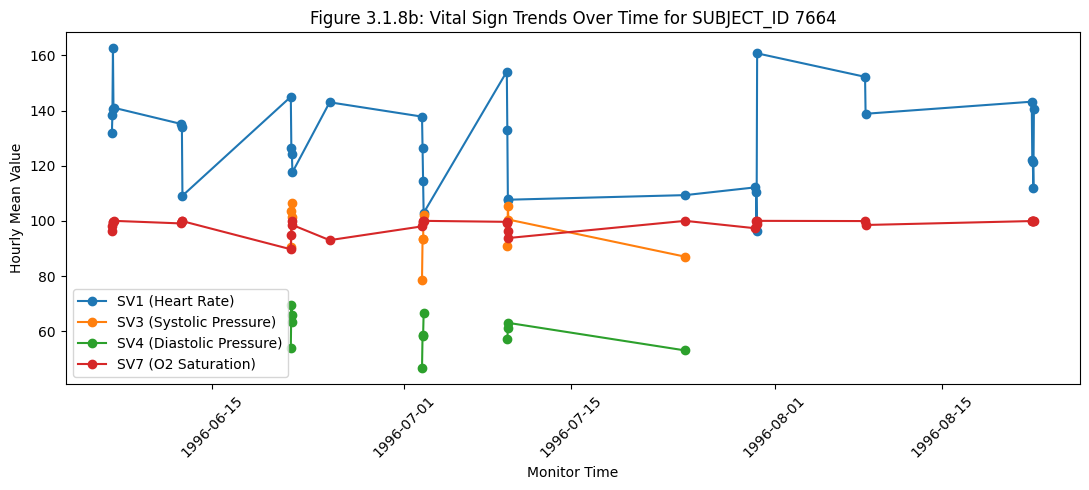

In [71]:
plt.figure(figsize=(11,5))

plt.plot(patient_df["MONITORTIME"], patient_df["SV1_mean"], marker="o", label="SV1 (Heart Rate)")
plt.plot(patient_df["MONITORTIME"], patient_df["SV3_mean"], marker="o", label="SV3 (Systolic Pressure)")
plt.plot(patient_df["MONITORTIME"], patient_df["SV4_mean"], marker="o", label="SV4 (Diastolic Pressure)")
plt.plot(patient_df["MONITORTIME"], patient_df["SV7_mean"], marker="o", label="SV7 (O2 Saturation)")

plt.title("Vital Sign Trends Over Time for SUBJECT_ID 7664")
plt.xlabel("Monitor Time")
plt.ylabel("Hourly Mean Value")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

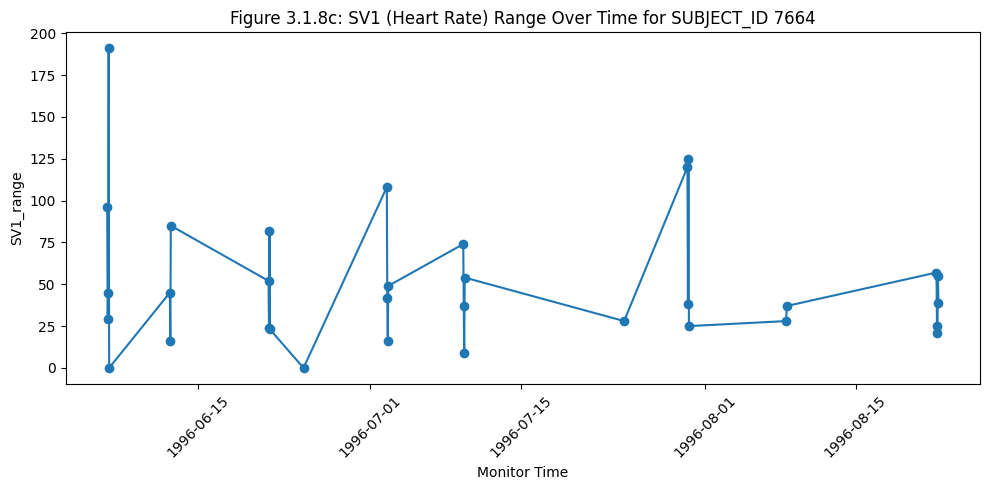

In [72]:
patient_df["SV1_range"] = patient_df["SV1_max"] - patient_df["SV1_min"]

plt.figure(figsize=(10,5))
plt.plot(patient_df["MONITORTIME"], patient_df["SV1_range"], marker="o")

plt.title("Figure 3.1.8c: SV1 (Heart Rate) Range Over Time for SUBJECT_ID 7664")
plt.xlabel("Monitor Time")
plt.ylabel("SV1_range")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()